<a href="https://colab.research.google.com/github/Madvillainism/Amaterasu-/blob/main/ImageToMusic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimated Tempo: [112.34714674] BPM


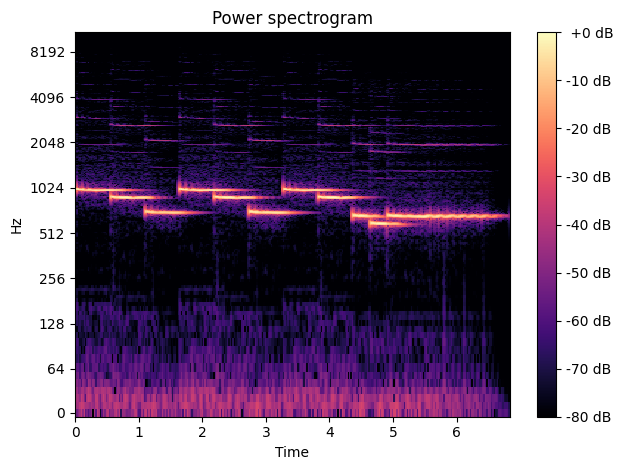

In [7]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import wavfile

def image_to_sound(image_path, output_path):
    # 1. Load and process
    img = Image.open(image_path).convert('L').resize((64, 64))
    pixels = np.array(img)

    # 2. Map pixels to frequencies
    w, h = pixels.shape
    duration = 0.1 # Duration per pixel
    sampling_rate = 44100
    total_audio = []

    for row in pixels:
        for pixel in row:
            # Map brightness to 200Hz - 1000Hz
            freq = 200 + (pixel / 255) * 800
            t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
            wave = 0.5 * np.sin(2 * np.pi * freq * t)
            total_audio.append(wave)

    # 3. Concatenate and save
    audio_data = np.concatenate(total_audio)
    wavfile.write(output_path, sampling_rate, audio_data.astype(np.float32))

# Usage
# image_to_sound('input.jpg', 'output.wav')

image_to_sound('sonic.jpg', 'fast.wav')

# Load audio file
y, sr = librosa.load('soh.mp3')

# Extract tempo and beats
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)

# Calculate MFCCs
mfccs = librosa.feature.mfcc(y=y, sr=sr)

print(f"Estimated Tempo: {tempo} BPM")

D = librosa.stft(y)  # STFT of y
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure()
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.title('Power spectrogram')
plt.colorbar(format='%+3.0f dB')
plt.tight_layout()
